Это вторая часть задания.

Первая часть задания (задания 3.1-3.4) находится в [ноутбуке про линейную регрессию](https://colab.research.google.com/drive/1eX21oBHRAzNr3PimxhMJENF3yeBC2DBe?usp=sharing).

# Предсказание цен на недвижимость

Компании по продаже недвижимости оценивают её стоимость, используя методы машинного обучения.
Задача оценки цены на недвижимость также может быть нужна для выявления наиболее выгодных предложений, или, например, для выявления аномально низких цен на объект недвижимости.

**Постановка задачи анализа данных**

Целью данной задачи является прогнозирование стоимости домов в округе Кинг (штат Вашингтон, США) с помощью построения регрессионных моделей и их анализа. Набор данных состоит из цен на дома в округе Кинг, проданных в период с мая 2014 года по май 2015 года. Данные опубликованы в открытом доступе на платформе Kaggle.

Данные с сайта renthub.com по стоимости квартир для аренды:

<a href="https://drive.google.com/uc?id=1Dr-p-o5yMi3uIS2kPcUUwT5bH0cCt1Be
" target="_blank"><img src="https://drive.google.com/uc?id=1Dr-p-o5yMi3uIS2kPcUUwT5bH0cCt1Be"
alt="IMAGE ALT TEXT HERE" width="360" border="0" /></a>


**Обзор доступных данных**

В наборе данных 21613 наблюдений и 16 признаков.
Таким образом, про каждый из 21613 объектов недвижимости мы знаем значения 16 характеристик (число спален, оценка состояния риелтором, наличие вида на воду и т.п.)

Выборка была разбита на две части для обучения и для тестирования модели. Данные на обучение и тест обычно делят случайно и равномерно: нужно чтобы и обучающая, и тестовая выборка были похожие на те данные, на которых модель будет использоваться в боевых условиях.

Более сложные разбиения могут использоваться если в данных есть временная компонента - например, мы строим скоринговую модель и для теста откладываем данные за последние несколько месяцев, а всю остальную выборку используем для обучения. Такое разбиение имитирует реальную работу модели: мы можем обучаться только на данных прошлых кредитов, а работать модель уже будет на данных из будущего.

Доли общей выборки для обучения и тестирования обычно 70% и 30% соотвественно. Любые разумные числа подходят, если для обучения используется достаточно много данных (обычно больше 50%), но и для тестирования что-то остается (10% и больше).


Данные содержат два типа переменных:

* Целевая: **Целевая. Цена**
* Остальные переменные **могут использоваться для прогноза целевой переменной.**

## План анализа данных (data mining):

  1. Загрузить данные для обучения
  2. Обработать данные перед обучением модели
  3. Обучить модель на обучающей выборке
  4. Загрузить и предобработать данные для тестирования
  5. Провалидировать модель на тестовой выборке
  6. Проанализировать важность признаков и не забыть про постановку задачи

## 1. Загрузить данные для обучения

**Шаг 1.1. Загружаем библиотеки**

Библиотека **warnings** отвечает за то, какие предупреждения (warnings) о работе будут выводиться пользователю.
FutureWarning - предупреждения о том, как изменится работа библиотек в будущих версиях.
Поэтому такие предупреждения мы будем игнорировать.
Чтобы включить режим игнорирования мы отбираем все предупреждения из категории FutureWarning и выбираем для них действия 'ignore'.
Это делается вызовом функции simplefilter c задание двух атрибутов: действия action и категории предупреждений category.

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

Для корректной работы с данными в python требуется загрузить специальную библиотеку
**pandas**, программную библиотеку на языке python для обработки и анализа данных.

In [2]:
import pandas as pd # загружаем библиотеку и для простоты обращения в коде называем её сокращенно pd

Для корректной работы с графиками в python требуется загрузить специальную библиотеку
**matplotlib**, программную библиотеку на языке python для визуализации данных двумерной и трехмерной графикой.

Графики используются для облегчения интерпретации полученных результатов, а также в качестве иллюстраций в презентациях и отчетах.

Оснвные методы для построения:
* plot() - графики
* semilogy() - график логарифмический
* hist() - гистограммы

In [3]:
import matplotlib.pyplot as plt # загружаем библиотеку и для простоты обращения в коде называем её сокращенно plt
# указываем, чтобы картинки отображались прямо в ноутбуке
%matplotlib inline

**Шаг 1.2. Загрузим данные**

Для решения задачи мы будем использовать данные. Они состоят из двух частей: часть для обучения и часть для тестирования модели. Загружаем данные с помощие команды !wget. Для того, чтобы игнорировать сообщения в процессе загрузки используем магическую команду %%capture в первой строке.

In [4]:
%%capture
!wget https://www.dropbox.com/s/afwb0tnqm9izxha/predict_house_price_training_data.xlsx
!wget https://www.dropbox.com/s/sur2avqf4n5f4az/predict_house_price_test_data.xlsx

Так как данные в формате xlsx (Excel), мы будем использовать специальную функцию
из библиотеки pandas для загрузки таких данных **read_excel**.

В функции передаем один атрибут: название таблицы с данными.

In [13]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   --------------------

In [14]:
training_data = pd.read_excel('data/predict_house_price_training_data.xlsx')


*Что важно посмотреть после того, как мы загрузили данные?*
- проверить, что данные действительно загрузились
- посмотреть на данные, чтобы удостовериться, что они правильные: колонки имеют те же названия, что и в таблице и т.д.

Для того чтобы это сделать, нужно вызвать от переменной *training_data* метод **head()**, который выводит первые 5 строк таблицы.

Для вызова метода объекта необходимо сначала написать *имя объекта*, затем поставить *точку*, затем уже написать *название метода*. Обратите внимание, что в конце обязательно ставить скобочки, потому что метод - это функция и в ней есть аргументы, просто в данном случае мы их не передаем, поэтому оставляем поле пустым

In [15]:
training_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,830000,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,385000,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,610000,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,550000,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,1300000,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


**Шаг 1.3. Посмотрим на размеры загруженной таблицы**, у которой мы видели только первые 5 строк.

Для этого вызываем поле **shape** у нашей переменной *training_data*. Поле вызывается также как метод, но в конце скобки не ставятся, так как для поля не предусмотрена передача аргументов.  

In [16]:
training_data.shape

(15129, 16)

*Что означает первое и второе число?*

Итак, таблица содержит 15129 строк (объектов) и 16 столбцов (признаков), включая выходной (целевой) признак.
15129 меньше 21613, так как мы пока загрузили только часть данных, которую будем использовать для обучения модели.

Таблицу проверили, теперь можно приступать к обработке данных.

# 2. Обработать данные перед обучением модели

**Шаг 2.1. Проверяем данные на наличие пропусков и типов переменных**

Начнем с проверки общей информации о данных.
Для того чтобы это сделать, нужно обратиться вызвать у переменной *training_data* метод **info()**.

Напомним, что в конце необходимо поставить скобочки.

In [17]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15129 entries, 0 to 15128
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         15129 non-null  int64  
 1   Спальни              15129 non-null  int64  
 2   Ванные               15129 non-null  float64
 3   Жилая площадь        15129 non-null  int64  
 4   Общая площадь        15129 non-null  int64  
 5   Количество этажей    15129 non-null  float64
 6   Вид на воду          15129 non-null  int64  
 7   Просмотрены ранее    15129 non-null  int64  
 8   Состояние            15129 non-null  int64  
 9   Оценка риелтора      15129 non-null  int64  
 10  Площадь без подвала  15129 non-null  int64  
 11  Площадь подвала      15129 non-null  int64  
 12  Год постройки        15129 non-null  int64  
 13  Год реновации        15129 non-null  int64  
 14  Широта               15129 non-null  float64
 15  Долгота              15129 non-null 

Анализируем результата выполнения команды:

* 15129 строк (entries)
* 16 столбцов (Data columns)

В данных присутствует всего два типа dtypes:
* int64 - целое число  (12 столбцов)
* float64 - дробное число (4 столбца)

Цифры в каждой строчке обозначают количество заполненных (*non-null*) значений. Так как эти цифры в каждой строчке совпадают с числом строк (15129), то в данных нет пропусков и можно двигаться дальше.

**Шаг 2.2. Работаем с целевой переменной**

*Какая переменная целевая?*

В данном случае по условию задачи мы должны прогнозировать стоимость, поэтому целевая переменная - это цена.

In [18]:
target_variable_name = 'Целевая.Цена'

Нам нужно выделить в отдельную переменную *training_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *training_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [19]:
training_values = training_data[target_variable_name]

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным.
Для это нужно у переменной *training_data* вызвать метод **drop()**. Результат мы записываем в новую переменную *training_points*. После выполнения запроса *training_points* будет содержать исходную таблицу без целевого столбца.

Обратите внимание, что в данном случае мы передаем два аргумента:
    1. target_variable_name - название столбца цены, который мы ранее записали в эту переменную и теперь хотим удалить из training_data
    2. axis=1 - означает, что мы удаляем столбец, а в случае axis=0 - означает, что мы удаляем строку

In [20]:
training_points = training_data.drop(target_variable_name, axis=1)

Можно посмотреть результаты этих действий, вызвав метод **head()** и поле **shape**, которыми мы пользовались ранее, но сейчас нужно вызывать их от новой переменной *training_points*.

In [21]:
training_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407


In [22]:
training_points.shape

(15129, 15)

Видно, что столбца действительно нет, а количество строк не изменилось. Данные в 5 первых строках такие же, как были ранее.

##   3. Обучить модель на обучающей выборке

**Шаг 3.1. Выбираем метод, который будем использовать**

Проще всего начать с простых методов.

На выбор метода для построения модели влияет набор признаков, размер выборки, интуиция про то, какая связь между входными переменными и целевой. Но часто решение принимается исходя из того, какая модель сработала лучше.

Для корректной работы с методами построения моделей в python требуется загрузить специальную библиотеку
**sklearn**, программную библиотеку на языке python для для машинного обучения и анализа данных.

Импортируем модуль из этой библиотеки:
 * *linear_model* - тут находятся все линейные модели

In [23]:
from sklearn import linear_model

Чтобы создать модель линейной регресии, пишем имя модуля 'linear_model', затем точку, затем название модели.

In [24]:
linear_regression_model = linear_model.LinearRegression() # создаем модель

In [25]:
linear_regression_model # смотрим, что получилось

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Шаг 3.2. Обучить модель**

Теперь, когда мы создали прототип модели, можем её обучить на обучающей выборке.

Для этого вызываем метод **fit()** и передаем ему на вход два аргумента:
таблицу входных признаков и столбец значений целевой переменной - (training_points, training_values)

In [26]:
linear_regression_model.fit(training_points, training_values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[ -33756.87, 43121.02, 115.35,..., 24.57, 570765.13,-108281.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](15,)","['Спальни','Ванные','Жилая площадь',...,'Год реновации','Широта','Долгота']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.626e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,14


## Задание 3.5

Реализуйте настройку параметров модели не с помощью встроенной функции, а с помощью своей реализации.

Настроить параметры нужно либо с помощью **стохастического градиентного спуска** либо с помощью **mini-batch градиентного спуска**.
Нужно использовать регуляризацию **L1, L2 или Elastic Net**.

### Алгоритм обучения модели

1. Получить на вход матрицу признаков `X` и вектор ответов `y`.

2. Преобразовать `X` и `y` в массивы `numpy`.

3. Привести `y` к одномерному виду.

4. Определить количество объектов и количество признаков:

   $$
   n\_objects, n\_features = X.shape
   $$

5. Создать генератор случайных чисел для выбора mini-batch.

6. Посчитать среднее и стандартное отклонение для каждого признака:

   $$
   X_{mean} = mean(X)
   $$

   $$
   X_{std} = std(X)
   $$

7. Если у какого-то признака стандартное отклонение равно нулю, заменить его на `1`, чтобы избежать деления на ноль:

   $$
   X_{std,j} = 1, \ если \ X_{std,j}=0
   $$

8. Стандартизировать признаки:

   $$
   X_{scaled} = \frac{X - X_{mean}}{X_{std}}
   $$

   Или заменить пункты 6-8 на готовое решение из [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html):
      ```python
      from sklearn.preprocessing import StandardScaler

      scaler = StandardScaler()
      # Fit to training data and transform it
      X_train_scaled = scaler.fit_transform(X_train)
      # Use SAME scaler to transform test data
      X_test_scaled = scaler.transform(X_test)
      ```

9. Посчитать среднее и стандартное отклонение целевой переменной `y`:

   $$
   y_{mean} = mean(y)
   $$

   $$
   y_{std} = std(y)
   $$

10. Если стандартное отклонение `y` равно нулю, заменить его на `1`:

   $$
   y_{std} = 1, \ если \ y_{std}=0
   $$

11. Стандартизировать целевую переменную:

   $$
   y_{scaled} = \frac{y - y_{mean}}{y_{std}}
   $$

   Или заменить пункты 9-11 на готовое решение из scikit-learn (см. выше), заменив X_train X_test на y_train y_test


12. Инициализировать веса модели нулями:

   $$
   w = 0
   $$

13. Инициализировать свободный член:

   $$
   b = 0
   $$

14. Создать список для хранения истории функции потерь.

15. Запустить цикл обучения на заданное количество итераций.

16. На каждой итерации случайно выбрать mini-batch из обучающей выборки.

17. Взять из данных признаки и ответы, соответствующие выбранным индексам:

   $$
   X_{batch}, y_{batch}
   $$

18. Посчитать предсказания модели на mini-batch:

   $$
   \hat{y}_{batch} = X_{batch}w + b
   $$

19. Посчитать ошибки:

   $$
   errors = \hat{y}_{batch} - y_{batch}
   $$

20. Посчитать градиент MSE по весам:

   $$
   grad_w = \frac{1}{m}X_{batch}^T errors
   $$

   где:

   $$
   m = len(y_{batch})
   $$

21. Добавить к градиенту штраф L2-регуляризации:

   $$
   grad_w = grad_w + \lambda_2 w
   $$

22. Добавить к градиенту штраф L1-регуляризации:

   $$
   grad_w = grad_w + \lambda_1 sign(w)
   $$

23. Посчитать градиент по свободному члену:

   $$
   grad_b = mean(errors)
   $$

24. Обновить веса:

   $$
   w = w - learning\_rate \cdot grad_w
   $$

25. Обновить свободный член:

   $$
   b = b - learning\_rate \cdot grad_b
   $$

26. Периодически считать функцию потерь на всей обучающей выборке.

27. Для этого посчитать предсказания на всех объектах:

   $$
   \hat{y} = X_{scaled}w + b
   $$

28. Посчитать MSE:

   $$
   MSE = mean((\hat{y} - y_{scaled})^2)
   $$

29. Посчитать регуляризационный штраф:

   $$
   Reg = \frac{\lambda_2}{2}\sum_j w_j^2 + \lambda_1\sum_j |w_j|
   $$

30. Посчитать полную функцию потерь:

   $$
   Loss = MSE + Reg
   $$

31. Сохранить значение `Loss` в историю обучения.

32. Сравнить текущее значение `Loss` с предыдущим:

   $$
   |Loss_{previous} - Loss_{current}|
   $$

33. Если изменение функции потерь меньше заданного порога `tol`, остановить обучение досрочно:

   $$
   |Loss_{previous} - Loss_{current}| < tol
   $$

34. Вернуть обученную модель.

In [27]:
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [29]:
training_data = pd.read_excel('data/predict_house_price_training_data.xlsx')
test_data = pd.read_excel('data/predict_house_price_test_data.xlsx')

In [30]:
training_values = training_data[target_variable_name]
training_points = training_data.drop(target_variable_name, axis=1)

test_values = test_data[target_variable_name]
test_points = test_data.drop(target_variable_name, axis=1)

In [31]:
class MiniBatchLinearRegression:
    """
    Линейная регрессия с mini-batch градиентным спуском
    и L2-регуляризацией
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, 
                 batch_size=32, lambda_l2=0.01, tol=1e-6, 
                 random_state=None, verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.lambda_l2 = lambda_l2 
        self.tol = tol
        self.random_state = random_state
        self.verbose = verbose
        
        self.w = None           
        self.b = None           
        self.loss_history = []  
        self.X_mean = None      
        self.X_std = None       
        self.y_mean = None      
        self.y_std = None      
        self.n_features = None
        
    def _scale_X(self, X, fit=True):
        """Стандартизация признаков"""
        if fit:
            self.X_mean = np.mean(X, axis=0)
            self.X_std = np.std(X, axis=0)
            self.X_std[self.X_std == 0] = 1  
        X_scaled = (X - self.X_mean) / self.X_std
        return X_scaled
    
    def _scale_y(self, y, fit=True):
        """Стандартизация целевой переменной"""
        if fit:
            self.y_mean = np.mean(y)
            self.y_std = np.std(y)
            if self.y_std == 0:
                self.y_std = 1
        y_scaled = (y - self.y_mean) / self.y_std
        return y_scaled
    
    def _inverse_scale_y(self, y_scaled):
        """Обратное преобразование целевой переменной"""
        return y_scaled * self.y_std + self.y_mean
    
    def _compute_loss(self, X, y):
        """Вычисление полной функции потерь (MSE + L2)"""
        y_pred = X @ self.w + self.b
        mse = np.mean((y_pred - y) ** 2)
        reg = (self.lambda_l2 / 2) * np.sum(self.w ** 2)
        return mse + reg
    
    def fit(self, X, y):

        X = np.array(X, dtype=np.float64)
        y = np.array(y, dtype=np.float64).reshape(-1)
        
        n_objects, n_features = X.shape
        self.n_features = n_features
        
        rng = np.random.RandomState(self.random_state)
        
        X_scaled = self._scale_X(X, fit=True)
        
        y_scaled = self._scale_y(y, fit=True)
        
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        self.loss_history = []
        
        prev_loss = float('inf')
        
        for iteration in range(self.n_iterations):
            indices = rng.choice(n_objects, size=min(self.batch_size, n_objects), replace=False)
            
            X_batch = X_scaled[indices]
            y_batch = y_scaled[indices]
            
            y_pred_batch = X_batch @ self.w + self.b
            
            errors = y_pred_batch - y_batch
            
            m = len(y_batch)
            grad_w = (X_batch.T @ errors) / m
            
            grad_w = grad_w + self.lambda_l2 * self.w
            
            grad_b = np.mean(errors)
            
            self.w = self.w - self.learning_rate * grad_w
            self.b = self.b - self.learning_rate * grad_b
            
            if iteration % 50 == 0 or iteration == self.n_iterations - 1:
                loss = self._compute_loss(X_scaled, y_scaled)
                self.loss_history.append(loss)
                
                if abs(prev_loss - loss) < self.tol and iteration > 100:
                    if self.verbose:
                        print(f"Early stopping at iteration {iteration}, loss: {loss:.6f}")
                    break
                prev_loss = loss
                
                if self.verbose and iteration % 200 == 0:
                    print(f"Iteration {iteration}: Loss = {loss:.6f}")
        
        return self
    
    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        X_scaled = self._scale_X(X, fit=False)
        
        y_pred_scaled = X_scaled @ self.w + self.b
        
        y_pred = self._inverse_scale_y(y_pred_scaled)
        
        return y_pred

In [33]:
my_model = MiniBatchLinearRegression(
    learning_rate=0.01,
    n_iterations=5000,
    batch_size=64,
    lambda_l2=0.001,
    tol=1e-8,
    random_state=42,
    verbose=True
)

my_model.fit(training_points, training_values)

Iteration 0: Loss = 0.980845
Iteration 200: Loss = 0.316689
Iteration 400: Loss = 0.311174
Iteration 600: Loss = 0.309672
Iteration 800: Loss = 0.309634
Iteration 1000: Loss = 0.314556
Iteration 1200: Loss = 0.309621
Iteration 1400: Loss = 0.309608
Iteration 1600: Loss = 0.309736
Iteration 1800: Loss = 0.314420
Iteration 2000: Loss = 0.309704
Iteration 2200: Loss = 0.311013
Iteration 2400: Loss = 0.309834
Iteration 2600: Loss = 0.309868
Iteration 2800: Loss = 0.311045
Iteration 3000: Loss = 0.310579
Iteration 3200: Loss = 0.310652
Iteration 3400: Loss = 0.310592
Iteration 3600: Loss = 0.311158
Iteration 3800: Loss = 0.311807
Iteration 4000: Loss = 0.311037
Iteration 4200: Loss = 0.310357
Iteration 4400: Loss = 0.310604
Iteration 4600: Loss = 0.311529
Iteration 4800: Loss = 0.309760


In [34]:
print(f"\nОбучение завершено! Всего итераций: {len(my_model.loss_history) * 50}")
print(f"Последнее значение loss: {my_model.loss_history[-1]:.6f}")


Обучение завершено! Всего итераций: 5050
Последнее значение loss: 0.310131


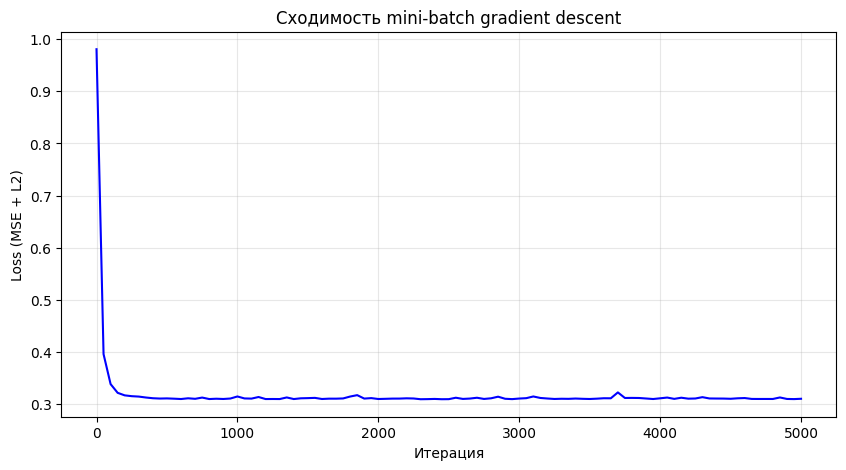

In [35]:
plt.figure(figsize=(10, 5))
plt.plot(range(0, len(my_model.loss_history) * 50, 50), my_model.loss_history, 'b-')
plt.xlabel('Итерация')
plt.ylabel('Loss (MSE + L2)')
plt.title('Сходимость mini-batch gradient descent')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Загрузить и предобработать данные для тестирования

**Шаг 4.1. Загрузим и проанализируем тестовые данные.**

Так как данные в формате xlsx (Excel), мы будем использовать специальную функцию
из библиотеки pandas для загрузки таких данных **read_excel**.

В функции передаем один атрибут: название файла, в котором находится таблица с данными.

In [36]:
test_data = pd.read_excel('data\predict_house_price_test_data.xlsx')

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Polina\AppData\Local\Temp\ipykernel_17488\1771745096.py:1: SyntaxWarning: invalid escape sequence '\p'
  test_data = pd.read_excel('data\predict_house_price_test_data.xlsx')


*Что важно посмотреть, после того, как мы загрузили данные?*

- проверить, что данные действительно загрузились
- посмотреть на данные, чтобы удостовериться, что они правильные: колонки имеют те же названия, что и в таблице и т.д.

Для того чтобы это сделать, нужно вызвать от переменной *test_data* метод **head()**, который выводит первые 5 строк таблицы.

Для вызова метода объекта необходимо сначала написать *имя объекта*, затем поставить *точку*, затем уже написать *название метода*. Обратите внимание, что в конце обязательно ставить скобочки, потому что метод - это функция и в ней есть аргументы, просто в данном случае мы их не передаем, поэтому оставляем поле пустым

In [37]:
test_data.head()

,Целевая.Цена,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,260000,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,734500,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,325000,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,1990000,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,315000,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


Посмотрим на размеры загруженной таблицы, так как мы видели только 5 строк

Для этого вызываем поле **shape** у нашей переменной *test_data*. Поле вызывается также как метод, но в конце скобки не ставятся (!), так как для поля не предусмотрена передача аргументов.  

In [38]:
test_data.shape

(6484, 16)

*Что означает первое и второе число?*
Таблица содержит 6484 строк (объектов) и 16 столбцов (признаков), включая выходной (целевой) признак. Также как в учебных данных до обучения.

Таблицу проверили, теперь можно приступать к обработке данных
Действуем аналогично тому, как делали с данными для обучения

Проверим, есть ли в данных пропуски. Для того чтобы это сделать, нужно обратиться вызвать у переменной *test_data* метод **info()**.

In [39]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6484 entries, 0 to 6483
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Целевая.Цена         6484 non-null   int64  
 1   Спальни              6484 non-null   int64  
 2   Ванные               6484 non-null   float64
 3   Жилая площадь        6484 non-null   int64  
 4   Общая площадь        6484 non-null   int64  
 5   Количество этажей    6484 non-null   float64
 6   Вид на воду          6484 non-null   int64  
 7   Просмотрены ранее    6484 non-null   int64  
 8   Состояние            6484 non-null   int64  
 9   Оценка риелтора      6484 non-null   int64  
 10  Площадь без подвала  6484 non-null   int64  
 11  Площадь подвала      6484 non-null   int64  
 12  Год постройки        6484 non-null   int64  
 13  Год реновации        6484 non-null   int64  
 14  Широта               6484 non-null   float64
 15  Долгота              6484 non-null   f

Цифры в каждой строчке обозначают количество заполненных (*non-null*) значений. Так как эти цифры в каждой строчке совпадают с числом строк (6484), то в данных нет пропусков.

**Шаг 4.2. Отделяем целевую переменную**

Нам нужно выделить в отдельную переменную *test_values* столбец из нашей таблицы, который соответствует определенной выше целевой переменной. Для этого мы у таблицы *test_data* в квадратных скобках указываем имя нужного столбца. В нашем случае это имя записано в переменной *target_variable_name*.

In [40]:
test_values = test_data[target_variable_name]

Отделим входные переменные от выходной (целевой), чтобы можно было построить модель предсказания целевой переменной по входным.
Для это нужно у переменной *test_data* вызвать метод **drop()**. Результат мы записываем в новую переменную *test_points*. После выполнения запроса *test_points* будет содержать исходную таблицу без целевого столбца.

Обратите внимание, что в данном случае мы передаем два аргумента:
    1. target_variable_name - название столбца цены, который мы ранее записали в эту переменную и теперь хотим удалить из training_data
    2. axis=1 - означает, что мы удаляем столбец, а в случае axis=0 - означает, что мы удаляем строку

In [41]:
test_points = test_data.drop(target_variable_name, axis=1)

И проверяем результат записанный в test_points

In [42]:
test_points.head()

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,3,1.00,1300,10139,1.0,0,0,3,7,1300,0,1962,2007,47.3427,-122.087
1,4,2.75,3280,6845,2.0,0,0,3,10,3280,0,2003,0,47.7042,-122.107
2,1,1.00,1220,12426,1.0,0,4,4,6,1220,0,1946,0,47.4047,-122.331
3,3,2.50,2880,13500,1.0,0,4,5,8,1520,1360,1950,0,47.6281,-122.216
4,3,2.00,1300,3731,1.0,0,0,3,7,900,400,1993,0,47.5374,-122.270


In [43]:
test_points.shape

(6484, 15)

Видно, что количество столбцов уменьшилось на один. Данные в 5 первых строках такие же, как были ранее.

# 5. Провалидировать модель на тестовой выборке

**Шаг 5.1. Сравнение моделей.**

Теперь мы готовы сравнить качество двух моделей! 😎

## Задание 3.6 Какая модель лучше?

Получим прогнозы целевой переменной на тестовых данных для модели линейной регрессии из sklearn и для своей реализации.



In [44]:
test_predictions_linear = linear_regression_model.predict(test_points)

In [45]:
### введите свой код
test_predictions_mymodel = my_model.predict(test_points)
### код для получения предсказаний с помощью своей реализации алгоритма настройки параметров модели


In [51]:
comparison_df = pd.DataFrame({
    'Истинная цена': test_values.values,
    'Sklearn Linear': test_predictions_linear,
    'Моя модель': test_predictions_mymodel,
    'Разница (Sklearn)': test_values.values - test_predictions_linear,
    'Разница (Моя)': test_values.values - test_predictions_mymodel
})

print(comparison_df.head(10).round(3))

   Истинная цена  Sklearn Linear   Моя модель  Разница (Sklearn)  \
0         260000      204625.964   231448.761          55374.036   
1         734500      984565.479   974345.027        -250065.479   
2         325000      439655.979   425395.496        -114655.979   
3        1990000     1037045.625  1011041.465         952954.375   
4         315000      235923.502   243741.457          79076.498   
5         959000      902750.750   890314.160          56249.250   
6        1310000      714095.311   709967.192         595904.689   
7         424240      641444.143   633017.070        -217204.143   
8         290000      285988.008   288624.770           4011.992   
9         406000      315967.282   330141.962          90032.718   

   Разница (Моя)  
0      28551.239  
1    -239845.027  
2    -100395.496  
3     978958.535  
4      71258.543  
5      68685.840  
6     600032.808  
7    -208777.070  
8       1375.230  
9      75858.038  


Качество регрессионных моделей оценим двумя способами:
1. Сравним визуально прогнозы с настоящими ценами (тестовые с предсказанием)
2. Сравним метрики качества MSE и MAE

Для корректного подсчета метрик качества модели в python требуется загрузить их из библиотеки **sklearn**.

Мы используем две метрики качества:
 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \hat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \hat{y}_i)^2$

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

Подсчитаем ошибки для линейной модели.

Для этого вызовем методы **mean_absolute_error()** и **mean_squared_error()**. На вход им передается столбец настоящих значений *test_values* и столбец значений, предсказанных моделью линейной регрессии *test_predictions_linear*.

In [54]:
mae_linear = mean_absolute_error(test_values, test_predictions_linear)
mse_linear = mean_squared_error(test_values, test_predictions_linear)

Подсчитайте ошибки для своей реализации модели.

In [57]:
mae_mymodel = mean_absolute_error(test_values, test_predictions_mymodel)
mse_mymodel = mean_squared_error(test_values, test_predictions_mymodel)

Теперь напечатаем полученные ошибки. Обычно смотрят на корень из среднеквадратичной ошибки, RMSE. Чтобы извлечь корень нам понадобится библиотека **Numpy**. С помощью неё можно быстро производить вычисления сразу над массивами чисел.

In [60]:
print(f"\nSklearn LinearRegression:")
print(f"   MAE  = {mae_linear:.2f}")
print(f"   MSE  = {mse_linear:.2f}")

print(f"\nМоя модель (Mini-batch GD + L2):")
print(f"   MAE  = {mae_mymodel:.2f}")
print(f"   MSE  = {mse_mymodel:.2f}")


Sklearn LinearRegression:
   MAE  = 126852.51
   MSE  = 40756843765.10

Моя модель (Mini-batch GD + L2):
   MAE  = 125891.74
   MSE  = 40931914786.44


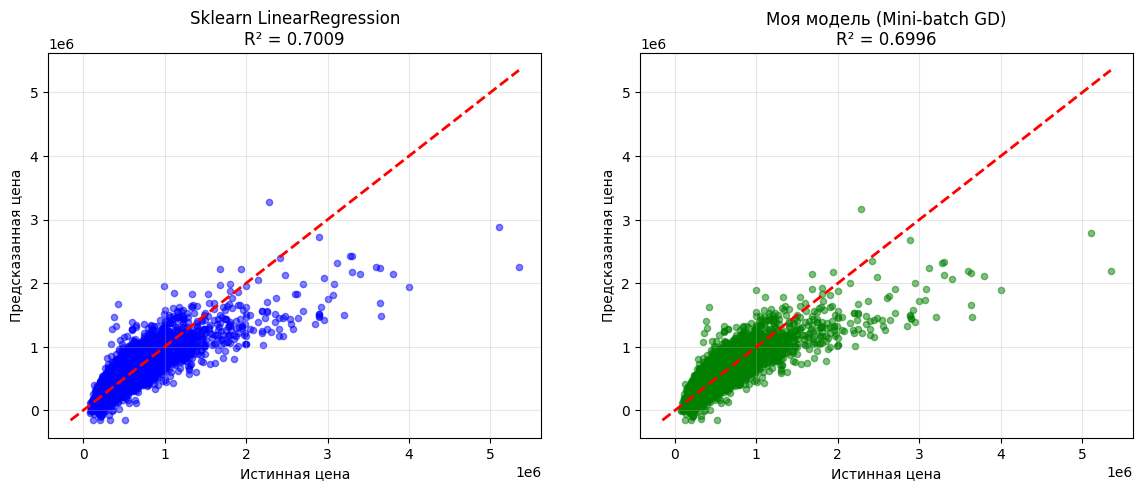

In [63]:
from sklearn.metrics import r2_score


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(test_values, test_predictions_linear, alpha=0.5, s=20, color='blue')
min_val = min(test_values.min(), test_predictions_linear.min())
max_val = max(test_values.max(), test_predictions_linear.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax1.set_xlabel('Истинная цена')
ax1.set_ylabel('Предсказанная цена')
ax1.set_title(f'Sklearn LinearRegression\nR² = {r2_score(test_values, test_predictions_linear):.4f}')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.scatter(test_values, test_predictions_mymodel, alpha=0.5, s=20, color='green')
min_val = min(test_values.min(), test_predictions_mymodel.min())
max_val = max(test_values.max(), test_predictions_mymodel.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
ax2.set_xlabel('Истинная цена')
ax2.set_ylabel('Предсказанная цена')
ax2.set_title(f'Моя модель (Mini-batch GD)\nR² = {r2_score(test_values, test_predictions_mymodel):.4f}')
ax2.grid(True, alpha=0.3)

plt.show()

## 6. Выявление важных признаков

Признаки, используемые для обучения модели, оказывают большое влияние на качество результатов. Неинформативные или слабо информативные признаки могут снизить качество модели, использование избыточных признаков в модели замедляет скорость ее работы.

Для того, чтобы отобрать признаки нам следует ответить на следующие вопросы:

    1. Все ли признаки в наших данных заполненны разумными значениями?
    2. Какие признаки будут больше всего влиять на значение целевой переменной?
    3. Какие дополнительные признаки имело бы смысл добавить в список входных?

**6.1. Разглядывание значений признаков**

Для того чтобы ответить на первый вопрос, нам необходимо получить некоторую нашу экспертную оценку данных. В наших данных нет пропусков, однако иногда пропуски предварительно заполняют другими значениями (0, 999 и другие) и их можно увидеть, только внимательно посмотрев на данные.

Для того, чтобы это сделать, нужно вызвать у переменной *training_points* метод **head(10)**, который выводит первые 10 строк таблицы.

In [ ]:
training_points.head(10)

,Спальни,Ванные,Жилая площадь,Общая площадь,Количество этажей,Вид на воду,Просмотрены ранее,Состояние,Оценка риелтора,Площадь без подвала,Площадь подвала,Год постройки,Год реновации,Широта,Долгота
0,5,3.50,3490,21780,2.0,0,0,3,8,3490,0,1996,0,47.6707,-122.144
1,4,1.75,2360,7620,1.0,0,0,4,7,1180,1180,1955,0,47.5278,-122.345
2,6,2.75,2040,8560,1.0,0,2,4,7,1100,940,1961,0,47.6160,-122.115
3,3,1.75,1940,8376,1.0,0,0,4,8,1290,650,1963,0,47.5586,-122.173
4,3,2.75,3450,5350,1.5,0,3,4,9,2590,860,1925,0,47.6389,-122.407
5,3,2.25,2300,9914,2.0,0,0,4,8,2300,0,1980,0,47.5677,-122.086
6,3,2.50,2770,8820,1.0,0,0,3,7,1900,870,1980,2004,47.3685,-122.048
7,2,1.75,1650,7500,1.0,0,0,4,7,1000,650,1959,0,47.6871,-122.207
8,1,1.00,580,1799,1.0,0,0,3,7,580,0,1908,2005,47.6829,-122.375
9,2,1.00,900,3400,1.0,0,0,5,6,900,0,1905,0,47.5269,-122.314


Рассмотрим столбец "Год реновации". Он содержит много нулей и мало реальных данных о годах, что как раз свидетельствует о том, что в этих данных изначально были пропуски, а к нам они попали уже заполненные нулями.

Мы можем посмотреть количество уникальных значений и сколько раз эти значения встречаются в этом столбце. Для этого вызываем метод **value_counts()** у нашего столбца *training_points['Год реновации']*

In [64]:
training_points['Год реновации'].value_counts()

Год реновации
0       14490
2014       63
2013       31
2000       28
2003       24
        ...  
1950        1
1954        1
1946        1
1959        1
1955        1
Name: count, Length: 67, dtype: int64

Как видно, нулей существенно больше (14490), чем любых других значений (639), поэтому можем сделать вывод, что этот признак не информативен и может негативно повлиять на качество модели.

**6.2. Какие признаки самые важные**

Ручной перебор признаков невозможен, если их тысячи, кроме того, часто даже эксперты не могут сказать, использование каких признаков в модели даст прирост качества.
Кроме ручного перебора всех признаков и их визуального анализа, можно использовать оценку значимости признаков с помощью обученных моделей.

## Задание 3.7

In [65]:
## введите свой код
feature_names = training_points.columns.tolist()
sklearn_importance = np.abs(linear_regression_model.coef_)
my_importance = np.abs(my_model.w * my_model.y_std / my_model.X_std)
## напишите код, который вычисляет значимость признака (фактически это просто вес по модулю)

Представьте полученные результаты в более удобном табличном виде. Создайте пустую таблицу *feature_importance* с двумя колонками "Название признака", "Важность признака". Для этого воспользуемся функцией **DataFrame()** из библиотеки pandas и передадим ей в качестве аргумента   
*columns = ["Название признака", "Важность признака"]*

In [66]:
feature_importance_sklearn = pd.DataFrame({
    'Название признака': feature_names,
    'Важность признака': sklearn_importance
})
feature_importance_my = pd.DataFrame({
    'Название признака': feature_names,
    'Важность признака': my_importance
})

Заполните соответствующие колонки значениями, которые мы получили выше.

Мы можем отсортировать значения по важности, вызвав у *feature_importance* метод **sort_values()**.

Обратите внимание, что в данном случае мы передаем два аргумента:

1. by='Важность признака' - название столбца, по которому мы сортируем
2. ascending=False - означает, что мы сортируем по убыванию, а в случае ascending=True сортировка будет по возрастанию

In [ ]:
feature_importance.sort_values(by='Важность признака', ascending=False)

,Название признака,Важность признака


<function matplotlib.pyplot.show(close=None, block=None)>

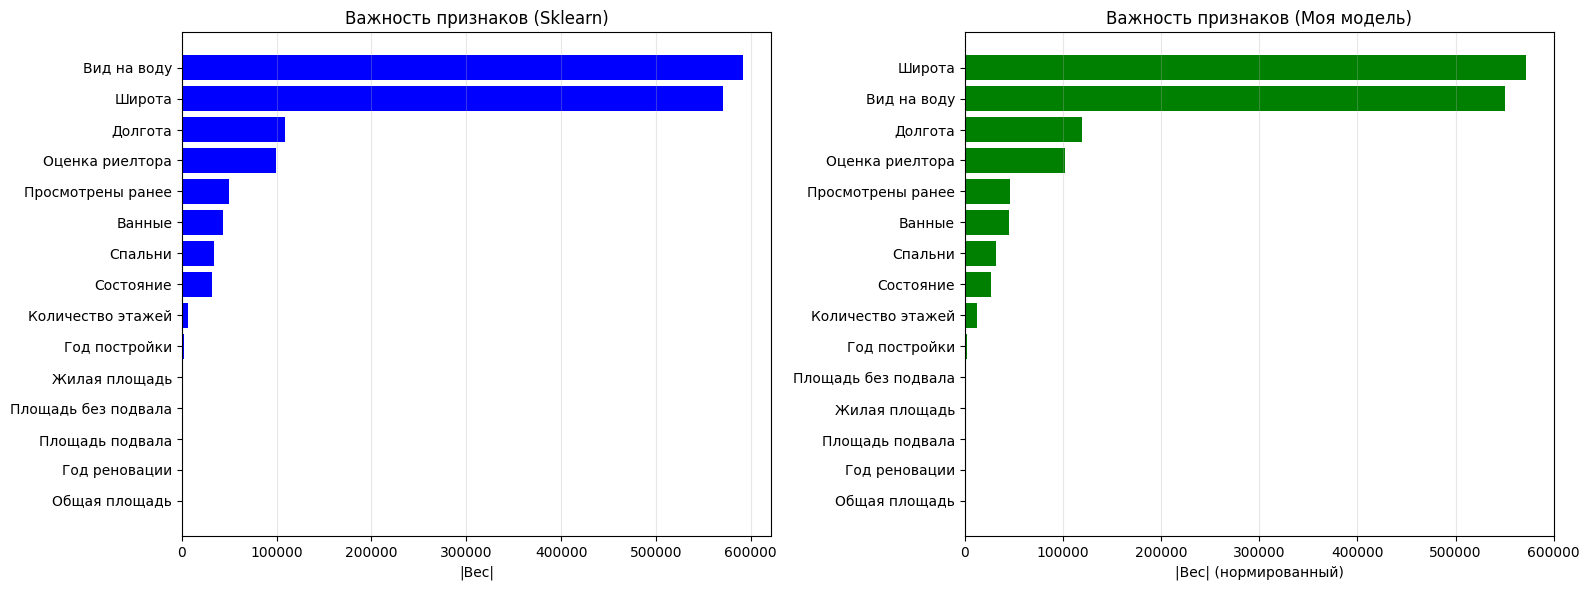

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
sorted_sklearn = feature_importance_sklearn.sort_values(by='Важность признака', ascending=True)
ax1.barh(sorted_sklearn['Название признака'], sorted_sklearn['Важность признака'], color='blue')
ax1.set_xlabel('|Вес|')
ax1.set_title('Важность признаков (Sklearn)')
ax1.grid(True, alpha=0.3, axis='x')

ax2 = axes[1]
sorted_my = feature_importance_my.sort_values(by='Важность признака', ascending=True)
ax2.barh(sorted_my['Название признака'], sorted_my['Важность признака'], color='green')
ax2.set_xlabel('|Вес| (нормированный)')
ax2.set_title('Важность признаков (Моя модель)')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show

### Ну вообще моя модель не так уж и плоха, даже признаки практически одинаково отранжировались 

## Задание 3.8.

Напомню исходную постановку задачи. Мы говорили о том, что оценка цены на недвижимость может быть нужна для выявления аномально низких цен на объект недвижимости. Давайте попробуем найти такие в датасете.


 Кол-во аномалий (Sklearn): 163
 Кол-во аномалий (Моя модель): 168

 Самые выгодные предложения (по Sklearn):
      Истинная цена  Sklearn Linear  Остаток (Sklearn)
5627        5350000      2261466.84         3088533.16
5462        5110000      2886122.70         2223877.30
2592        3650000      1486443.60         2163556.40
4175        4000000      1934875.59         2065124.41
5202        3640000      1680277.31         1959722.69
2068        3200000      1497726.24         1702273.76
5718        3800000      2146280.11         1653719.89
483         2950000      1422634.56         1527365.44
5597        2850000      1353981.96         1496018.04
4811        2900000      1461434.80         1438565.20


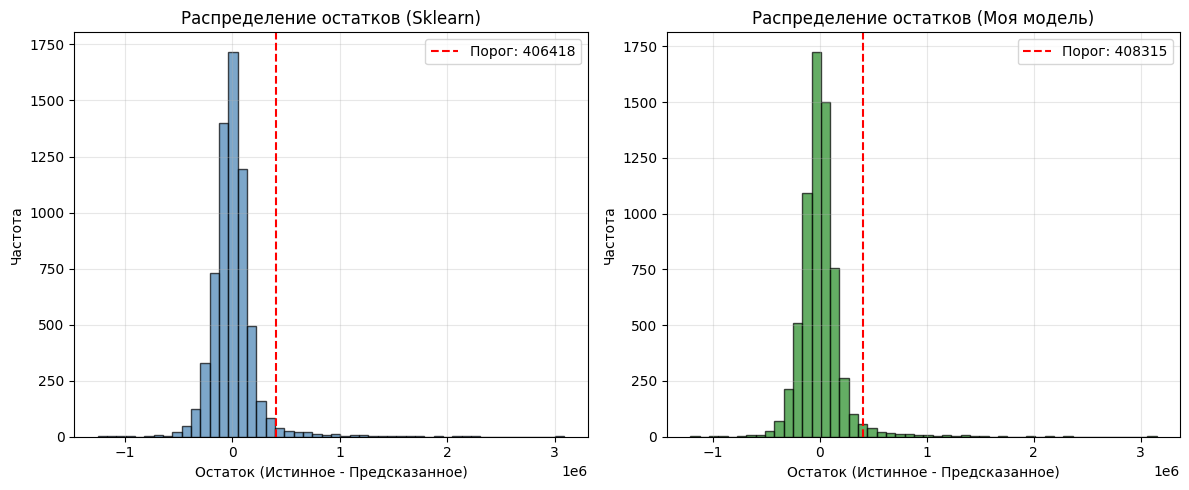

In [ ]:
residuals_sklearn = test_values - test_predictions_linear
residuals_my = test_values - test_predictions_mymodel

comparison_df['Остаток (Sklearn)'] = residuals_sklearn
comparison_df['Остаток (Моя)'] = residuals_my

threshold_sklearn = residuals_sklearn.mean() + 2 * residuals_sklearn.std()
threshold_my = residuals_my.mean() + 2 * residuals_my.std()

anomalies_sklearn = comparison_df[comparison_df['Остаток (Sklearn)'] > threshold_sklearn]
anomalies_my = comparison_df[comparison_df['Остаток (Моя)'] > threshold_my]

print(f"\n Кол-во аномалий (Sklearn): {len(anomalies_sklearn)}")
print(f" Кол-во аномалий (Моя модель): {len(anomalies_my)}")

print("\n Самые выгодные предложения (по Sklearn):")
top_deals = comparison_df.nlargest(10, 'Остаток (Sklearn)')[['Истинная цена', 'Sklearn Linear', 'Остаток (Sklearn)']]
print(top_deals.round(2))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(residuals_sklearn, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(threshold_sklearn, color='r', linestyle='--', label=f'Порог: {threshold_sklearn:.0f}')
plt.xlabel('Остаток (Истинное - Предсказанное)')
plt.ylabel('Частота')
plt.title('Распределение остатков (Sklearn)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals_my, bins=50, edgecolor='black', alpha=0.7, color='forestgreen')
plt.axvline(threshold_my, color='r', linestyle='--', label=f'Порог: {threshold_my:.0f}')
plt.xlabel('Остаток (Истинное - Предсказанное)')
plt.ylabel('Частота')
plt.title('Распределение остатков (Моя модель)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()